# 07 Model Interpretability

This notebook explains the final cardiac arrest risk prediction model saved at `models/best_model.joblib`. If the model artifact is missing, it retrains the same candidate model family and selection workflow used in `notebooks/05_predictive_modeling.ipynb` so the interpretability analysis remains reproducible.

Interpretability outputs are saved to `reports/figures/`:

- `final_model_permutation_importance.png`
- `final_model_shap_importance.png` when SHAP is compatible with the final model
- `final_model_shap_summary.png` when SHAP is compatible with the final model

**Important limitation:** model explanations describe predictive patterns learned from this dataset. They do **not** establish causal effects or prove that changing a predictor would change cardiac arrest risk.

In [1]:
from pathlib import Path
import sys
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, f1_score, make_scorer, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.features import add_clinical_features

DATA_PATH = PROJECT_ROOT / 'data' / 'CardiacPatientData.csv'
MODEL_PATH = PROJECT_ROOT / 'models' / 'best_model.joblib'
REPORTS_DIR = PROJECT_ROOT / 'reports'
FIGURES_DIR = REPORTS_DIR / 'figures'
MODEL_COMPARISON_PATH = REPORTS_DIR / 'model_comparison.csv'

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE = 0.20
POS_LABEL = 1
sns.set_theme(style='whitegrid')

## Recreate the leakage safe hold-out split

The split mirrors the predictive modeling and final evaluation notebooks. `ID` is excluded from model inputs so the model cannot memorize patient identifiers. Deterministic clinical features are added after splitting.

In [2]:
df = pd.read_csv(DATA_PATH)

id_counts = df['ID'].value_counts()
ids_repeat = bool((id_counts > 1).any())
X_raw = df.drop(columns=['Outcome'])
y = df['Outcome'].astype(int)

if ids_repeat:
    holdout_splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    train_idx, test_idx = next(holdout_splitter.split(X_raw, y, groups=df['ID']))
    split_strategy = 'StratifiedGroupKFold by patient ID'
else:
    train_idx, test_idx = train_test_split(
        np.arange(len(df)),
        test_size=TEST_SIZE,
        stratify=y,
        random_state=RANDOM_STATE,
    )
    split_strategy = 'Stratified train/test split'

train_raw = df.iloc[train_idx].copy()
test_raw = df.iloc[test_idx].copy()

train_features = add_clinical_features(train_raw.drop(columns=['Outcome']))
test_features = add_clinical_features(test_raw.drop(columns=['Outcome']))
y_train = train_raw['Outcome'].astype(int)
y_test = test_raw['Outcome'].astype(int)
groups_train = train_raw['ID']

X_train = train_features.drop(columns=['ID'])
X_test = test_features.drop(columns=['ID'])

categorical_features = [
    'Gender', 'Alcoholic', 'Smoke', 'FHCD', 'TriageScore', 'age_band', 'gcs_severity',
    'hypoxemia_flag', 'sodium_abnormal_flag', 'potassium_abnormal_flag',
    'chloride_abnormal_flag', 'urea_abnormal_flag', 'creatinine_abnormal_flag',
]
categorical_features = [col for col in categorical_features if col in X_train.columns]
numeric_features = [col for col in X_train.columns if col not in categorical_features]

def prepare_model_matrix(X):
    X_model = X.copy()
    for col in categorical_features:
        X_model[col] = X_model[col].astype('object').where(X_model[col].notna(), np.nan)
    return X_model

X_train_model = prepare_model_matrix(X_train)
X_test_model = prepare_model_matrix(X_test)

print(f'Split strategy: {split_strategy}')
print(f'Train rows: {len(train_raw):,}; test rows: {len(test_raw):,}')
print(f'Test event rate: {y_test.mean():.3f}')
print(f'Numeric features ({len(numeric_features)}): {numeric_features}')
print(f'Categorical features ({len(categorical_features)}): {categorical_features}')

Split strategy: StratifiedGroupKFold by patient ID
Train rows: 4,746; test rows: 1,160
Test event rate: 0.873
Numeric features (15): ['SBP', 'DBP', 'HR', 'RR', 'BT', 'SpO2', 'Age', 'GCS', 'Na', 'K', 'Cl', 'Urea', 'Ceratinine', 'pulse_pressure', 'shock_index']
Categorical features (13): ['Gender', 'Alcoholic', 'Smoke', 'FHCD', 'TriageScore', 'age_band', 'gcs_severity', 'hypoxemia_flag', 'sodium_abnormal_flag', 'potassium_abnormal_flag', 'chloride_abnormal_flag', 'urea_abnormal_flag', 'creatinine_abnormal_flag']


## Load or train the final model

The preferred path is to load `models/best_model.joblib`. If that file is unavailable, this notebook retrains the candidate models from the modeling notebook and selects the model with the best held-out AUROC, using AUPRC and F1 as tie-breakers. In the existing model comparison report, the selected final model is Random Forest.

In [3]:
def build_preprocessor():
    numeric_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ])
    categorical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])
    return ColumnTransformer(
        transformers=[
            ('numeric', numeric_pipeline, numeric_features),
            ('categorical', categorical_pipeline, categorical_features),
        ],
        sparse_threshold=0.0,
    )


def train_final_model_if_needed():
    preprocessor = build_preprocessor()
    if ids_repeat:
        cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
        cv_strategy = 'StratifiedGroupKFold by patient ID'
    else:
        cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
        cv_strategy = 'StratifiedKFold'

    scoring = {
        'auroc': 'roc_auc',
        'auprc': 'average_precision',
        'f1': make_scorer(f1_score, zero_division=0),
        'sensitivity': make_scorer(recall_score, zero_division=0),
        'precision': make_scorer(precision_score, zero_division=0),
    }
    model_specs = {
        'Logistic Regression': {
            'pipeline': Pipeline([
                ('preprocess', preprocessor),
                ('model', LogisticRegression(C=np.inf, solver='lbfgs', max_iter=2000, random_state=RANDOM_STATE)),
            ]),
            'param_grid': {'model__class_weight': [None, 'balanced']},
        },
        'Regularized Logistic Regression': {
            'pipeline': Pipeline([
                ('preprocess', preprocessor),
                ('model', LogisticRegression(solver='saga', max_iter=2000, random_state=RANDOM_STATE)),
            ]),
            'param_grid': {
                'model__C': [0.1, 1.0, 10.0],
                'model__l1_ratio': [0.0, 0.5, 1.0],
                'model__class_weight': [None, 'balanced'],
            },
        },
        'Random Forest': {
            'pipeline': Pipeline([
                ('preprocess', preprocessor),
                ('model', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
            ]),
            'param_grid': {
                'model__n_estimators': [200],
                'model__max_depth': [None, 8],
                'model__min_samples_leaf': [1, 5],
                'model__class_weight': [None],
            },
        },
        'Gradient Boosting': {
            'pipeline': Pipeline([
                ('preprocess', preprocessor),
                ('model', GradientBoostingClassifier(random_state=RANDOM_STATE)),
            ]),
            'param_grid': {
                'model__n_estimators': [100],
                'model__learning_rate': [0.03, 0.1],
                'model__max_depth': [2, 3],
                'model__subsample': [1.0],
            },
        },
    }

    rows = []
    fitted_searches = {}
    fit_kwargs = {'groups': groups_train} if ids_repeat else {}
    for model_name, spec in model_specs.items():
        print(f'Tuning {model_name}...')
        search = GridSearchCV(
            estimator=spec['pipeline'],
            param_grid=spec['param_grid'],
            scoring=scoring,
            refit='auroc',
            cv=cv,
            n_jobs=-1,
            return_train_score=False,
            error_score='raise',
        )
        search.fit(X_train_model, y_train, **fit_kwargs)
        fitted_searches[model_name] = search
        estimator = search.best_estimator_
        y_score = estimator.predict_proba(X_test_model)[:, 1]
        y_pred = (y_score >= 0.5).astype(int)
        rows.append({
            'model': model_name,
            'cv_strategy': cv_strategy,
            'best_params': search.best_params_,
            'cv_mean_auroc': search.best_score_,
            'test_auroc': roc_auc_score(y_test, y_score),
            'test_auprc': average_precision_score(y_test, y_score),
            'test_f1': f1_score(y_test, y_pred, zero_division=0),
        })
    comparison = pd.DataFrame(rows).sort_values(
        by=['test_auroc', 'test_auprc', 'test_f1'], ascending=False
    ).reset_index(drop=True)
    best_name = comparison.loc[0, 'model']
    best_estimator = fitted_searches[best_name].best_estimator_
    joblib.dump(best_estimator, MODEL_PATH)
    return best_estimator, best_name, comparison

if MODEL_PATH.exists():
    model = joblib.load(MODEL_PATH)
    if MODEL_COMPARISON_PATH.exists():
        comparison_df = pd.read_csv(MODEL_COMPARISON_PATH)
        model_name = comparison_df.iloc[0]['model']
    else:
        model_name = type(model.named_steps['model']).__name__
    print(f'Loaded final model from {MODEL_PATH.relative_to(PROJECT_ROOT)}')
else:
    print(f'{MODEL_PATH.relative_to(PROJECT_ROOT)} not found; retraining final model.')
    model, model_name, comparison_df = train_final_model_if_needed()

final_estimator = model.named_steps['model']
y_score = model.predict_proba(X_test_model)[:, 1]
print(f'Final model: {model_name} ({type(final_estimator).__name__})')
print(f'Held-out AUROC: {roc_auc_score(y_test, y_score):.3f}')
print(f'Held-out AUPRC: {average_precision_score(y_test, y_score):.3f}')
display(comparison_df.head())

Loaded final model from models/best_model.joblib


Final model: Random Forest (RandomForestClassifier)
Held-out AUROC: 0.881
Held-out AUPRC: 0.980


,model,selection_metric,cv_strategy,train_test_split_strategy,train_rows,test_rows,train_unique_ids,test_unique_ids,overlapping_train_test_ids,best_params,...,test_f1,test_sensitivity,test_specificity,test_precision,test_npv,true_negative,false_positive,false_negative,true_positive,rank_by_test_auroc
0,Random Forest,cv_mean_auroc,StratifiedGroupKFold by patient ID,StratifiedGroupKFold by patient ID,4746,1160,90,22,0,"{'model__class_weight': None, 'model__max_dept...",...,0.939098,0.997038,0.129252,0.887522,0.863636,19,128,3,1010,1
1,Gradient Boosting,cv_mean_auroc,StratifiedGroupKFold by patient ID,StratifiedGroupKFold by patient ID,4746,1160,90,22,0,"{'model__learning_rate': 0.03, 'model__max_dep...",...,0.926187,0.972359,0.122449,0.884201,0.391304,18,129,28,985,2
2,Regularized Logistic Regression,cv_mean_auroc,StratifiedGroupKFold by patient ID,StratifiedGroupKFold by patient ID,4746,1160,90,22,0,"{'model__C': 0.1, 'model__class_weight': 'bala...",...,0.896381,0.892399,0.319728,0.900398,0.301282,47,100,109,904,3
3,Logistic Regression,cv_mean_auroc,StratifiedGroupKFold by patient ID,StratifiedGroupKFold by patient ID,4746,1160,90,22,0,{'model__class_weight': 'balanced'},...,0.911824,0.898322,0.503401,0.925738,0.418079,74,73,103,910,4


## Logistic regression coefficients, when applicable

If the final estimator is linear logistic regression, the table below reports coefficients on the preprocessed design matrix. Positive coefficients increase predicted log-odds of `Outcome = 1`; negative coefficients decrease predicted log-odds. Because the current final model is Random Forest, coefficient interpretation is not applicable unless a logistic model is selected in a future run.

In [4]:
def get_transformed_feature_names(fitted_pipeline):
    preprocessor = fitted_pipeline.named_steps['preprocess']
    return preprocessor.get_feature_names_out()

feature_names = get_transformed_feature_names(model)

if isinstance(final_estimator, LogisticRegression):
    coefficients = pd.DataFrame({
        'feature': feature_names,
        'coefficient': final_estimator.coef_.ravel(),
    })
    coefficients['abs_coefficient'] = coefficients['coefficient'].abs()
    coefficients = coefficients.sort_values('abs_coefficient', ascending=False).reset_index(drop=True)
    display(coefficients.head(30))
else:
    coefficients = pd.DataFrame(columns=['feature', 'coefficient', 'abs_coefficient'])
    print(f'Final estimator is {type(final_estimator).__name__}; logistic regression coefficients are not applicable.')

Final estimator is RandomForestClassifier; logistic regression coefficients are not applicable.


## Permutation importance for the final model

Permutation importance is model-agnostic. Each feature is shuffled in the held-out set while all other features are left unchanged. The resulting decrease in AUROC estimates how much the trained pipeline depends on that feature for discrimination.

,feature,importance_mean,importance_std
0,shock_index,0.049555,0.005505
1,HR,0.045517,0.005112
2,Age,0.036148,0.008597
3,FHCD,0.017945,0.002091
4,Urea,0.013247,0.002499
5,TriageScore,0.011035,0.003847
6,Cl,0.009405,0.001530
7,Ceratinine,0.007535,0.001141
8,Smoke,0.007317,0.001748
9,chloride_abnormal_flag,0.005879,0.000911


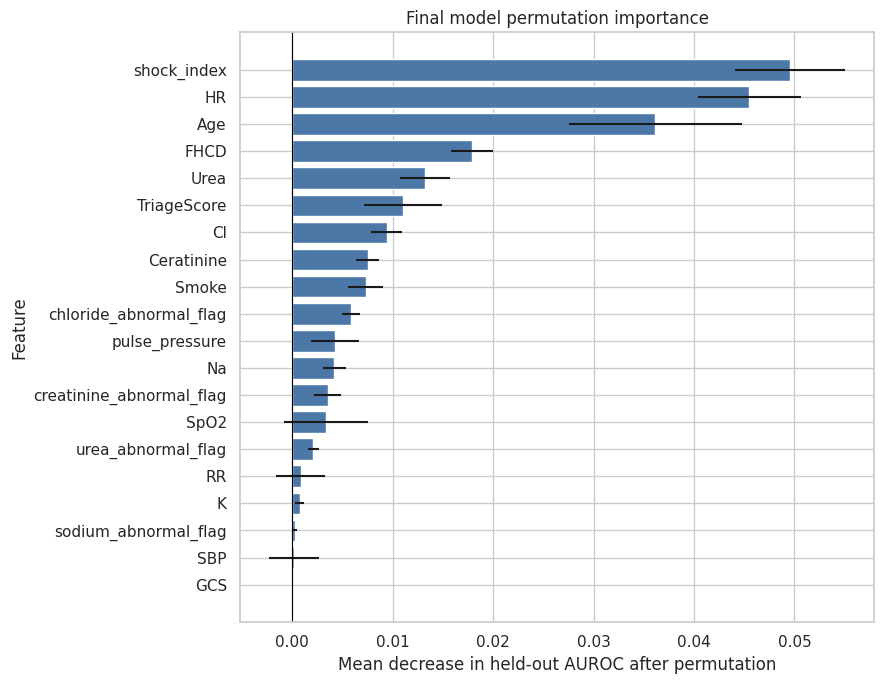

Saved permutation importance plot to: reports/figures/final_model_permutation_importance.png


In [5]:
perm = permutation_importance(
    model,
    X_test_model,
    y_test,
    scoring='roc_auc',
    n_repeats=30,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

permutation_df = pd.DataFrame({
    'feature': X_test_model.columns,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std,
}).sort_values('importance_mean', ascending=False).reset_index(drop=True)

display(permutation_df.head(20))

plot_df = permutation_df.head(20).sort_values('importance_mean')
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(plot_df['feature'], plot_df['importance_mean'], xerr=plot_df['importance_std'], color='#4c78a8')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Mean decrease in held-out AUROC after permutation')
ax.set_ylabel('Feature')
ax.set_title('Final model permutation importance')
fig.tight_layout()
perm_path = FIGURES_DIR / 'final_model_permutation_importance.png'
fig.savefig(perm_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved permutation importance plot to: {perm_path.relative_to(PROJECT_ROOT)}')

## SHAP values, when compatible

SHAP is attempted for tree-based and linear final estimators. For tree models, SHAP values are computed on the preprocessed feature matrix so one-hot encoded categories can be interpreted directly. For logistic regression, SHAP explains the linear decision function on the transformed matrix. If the final model type is unsupported, this section reports that SHAP is unavailable instead of forcing an incompatible explanation.

,feature,mean_abs_shap
0,numeric__SpO2,0.036891
1,numeric__shock_index,0.028354
2,numeric__HR,0.026520
3,numeric__Age,0.024138
4,numeric__RR,0.016923
5,numeric__Urea,0.012297
6,categorical__age_band_80+,0.012244
7,numeric__pulse_pressure,0.011279
8,categorical__TriageScore_2.0,0.009050
9,numeric__SBP,0.009017


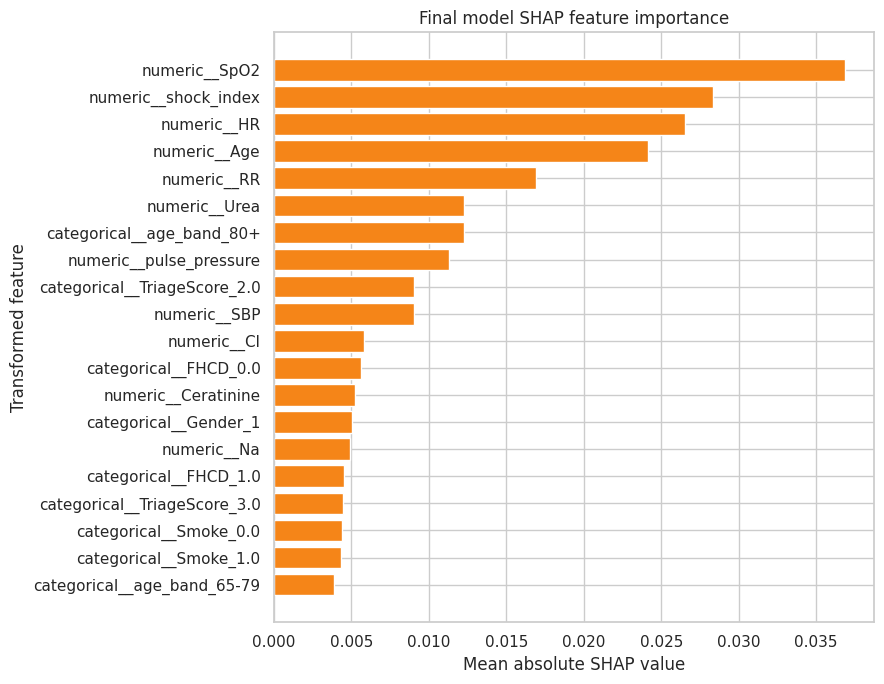

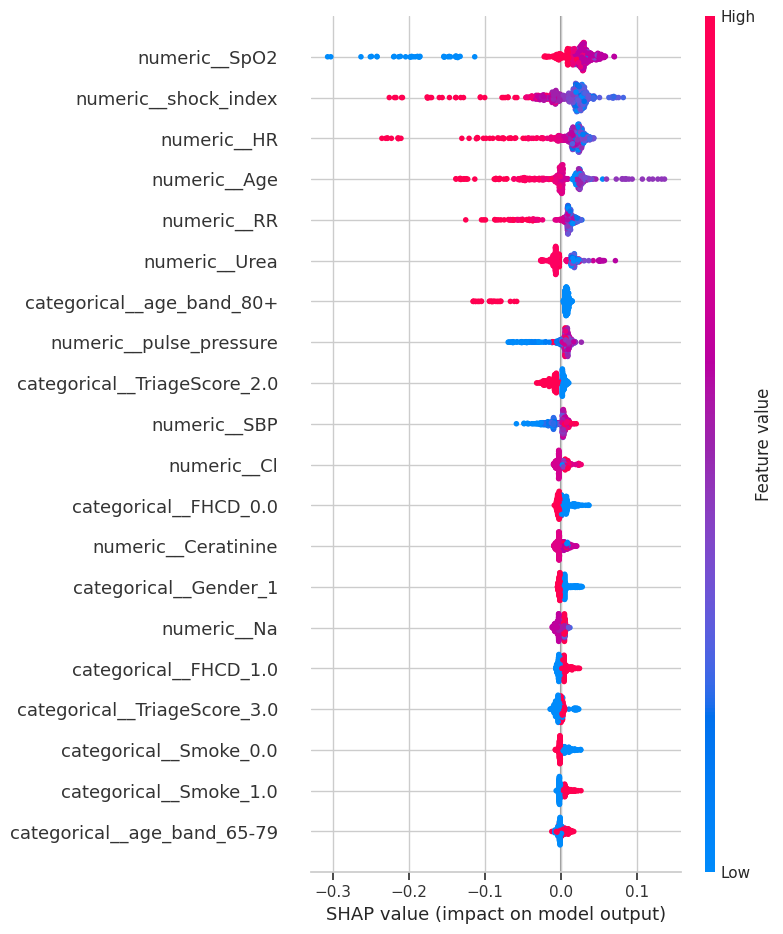

Saved SHAP importance plot to: reports/figures/final_model_shap_importance.png
Saved SHAP summary plot to: reports/figures/final_model_shap_summary.png


In [6]:
try:
    import shap
    shap_available = True
except ImportError:
    shap_available = False
    print('SHAP is not installed; skipping SHAP analysis.')

X_test_transformed = model.named_steps['preprocess'].transform(X_test_model)
X_test_transformed = pd.DataFrame(X_test_transformed, columns=feature_names, index=X_test_model.index)

shap_df = pd.DataFrame()
if shap_available:
    shap_sample = X_test_transformed.sample(n=min(500, len(X_test_transformed)), random_state=RANDOM_STATE)
    try:
        if isinstance(final_estimator, (RandomForestClassifier, GradientBoostingClassifier)):
            explainer = shap.TreeExplainer(final_estimator)
            shap_values = explainer.shap_values(shap_sample)
            if isinstance(shap_values, list):
                class_shap_values = shap_values[1]
            elif getattr(shap_values, 'ndim', 0) == 3:
                class_shap_values = shap_values[:, :, 1]
            else:
                class_shap_values = shap_values
        elif isinstance(final_estimator, LogisticRegression):
            explainer = shap.LinearExplainer(final_estimator, shap_sample)
            class_shap_values = explainer.shap_values(shap_sample)
        else:
            raise TypeError(f'SHAP not configured for {type(final_estimator).__name__}')

        shap_df = pd.DataFrame({
            'feature': shap_sample.columns,
            'mean_abs_shap': np.abs(class_shap_values).mean(axis=0),
        }).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
        display(shap_df.head(20))

        shap_plot_df = shap_df.head(20).sort_values('mean_abs_shap')
        fig, ax = plt.subplots(figsize=(9, 7))
        ax.barh(shap_plot_df['feature'], shap_plot_df['mean_abs_shap'], color='#f58518')
        ax.set_xlabel('Mean absolute SHAP value')
        ax.set_ylabel('Transformed feature')
        ax.set_title('Final model SHAP feature importance')
        fig.tight_layout()
        shap_importance_path = FIGURES_DIR / 'final_model_shap_importance.png'
        fig.savefig(shap_importance_path, dpi=300, bbox_inches='tight')
        plt.show()

        shap.summary_plot(class_shap_values, shap_sample, max_display=20, show=False)
        shap_summary_path = FIGURES_DIR / 'final_model_shap_summary.png'
        plt.gcf().savefig(shap_summary_path, dpi=300, bbox_inches='tight')
        plt.show()
        print(f'Saved SHAP importance plot to: {shap_importance_path.relative_to(PROJECT_ROOT)}')
        print(f'Saved SHAP summary plot to: {shap_summary_path.relative_to(PROJECT_ROOT)}')
    except Exception as exc:
        print(f'SHAP analysis skipped because it is not compatible in this run: {exc}')

## Clinical interpretation of top predictors

The ranking below prioritizes permutation importance because it is available for any final model type and measures the effect of disrupting each original clinical feature on held-out AUROC. SHAP rankings, when available, provide a complementary transformed-feature view.

In [7]:
clinical_notes = {
    'SpO2': 'Lower oxygen saturation or hypoxemia is clinically plausible because hypoxia can accompany respiratory failure, shock, and impending arrest.',
    'HR': 'Heart rate is plausible because tachycardia, bradycardia, or autonomic compensation may signal hemodynamic instability.',
    'SBP': 'Systolic blood pressure is plausible because hypotension can reflect shock or poor perfusion.',
    'DBP': 'Diastolic blood pressure is plausible because very low diastolic pressure can indicate vasodilation or compromised coronary perfusion; together with SBP it also defines pulse pressure.',
    'GCS': 'Glasgow Coma Scale is plausible because altered consciousness can reflect hypoxia, hypoperfusion, neurologic injury, or severe systemic illness.',
    'TriageScore': 'Triage acuity is plausible because it summarizes clinician-observed urgency at presentation.',
    'Na': 'Sodium is plausible because major electrolyte derangements can reflect severe illness and may contribute to neurologic or cardiac instability.',
    'K': 'Potassium is highly plausible because potassium abnormalities can directly affect cardiac conduction and arrhythmia risk.',
    'Cl': 'Chloride is plausible as a marker of acid-base and fluid/electrolyte disturbances, though it may be less directly actionable than potassium.',
    'Urea': 'Urea is plausible because renal dysfunction, dehydration, or catabolic stress can track severity of illness.',
    'Ceratinine': 'Creatinine is plausible because impaired renal function is associated with electrolyte disturbance, medication accumulation, and systemic illness severity.',
    'Age': 'Age is plausible because older patients often have less physiologic reserve and higher burden of cardiovascular and renal disease.',
    'Smoke': 'Smoking is plausible as a cardiovascular and pulmonary risk factor, but its acute predictive role may be weaker than vital signs and labs.',
    'Alcoholic': 'Alcohol use is plausible as a marker of cardiomyopathy, arrhythmia risk, trauma, intoxication, or chronic illness, but coding may be coarse.',
    'FHCD': 'Family history of cardiac disease is plausible for baseline cardiovascular susceptibility, although it may not capture acute physiologic deterioration.',
    'RR': 'Respiratory rate is plausible because respiratory distress, metabolic acidosis, or shock can precede arrest.',
    'BT': 'Body temperature is plausible because fever, hypothermia, or sepsis can reflect severe systemic stress.',
    'pulse_pressure': 'Pulse pressure is plausible because it summarizes SBP-DBP differences linked to perfusion and vascular tone.',
    'shock_index': 'Shock index is plausible because HR/SBP captures compensatory tachycardia relative to blood pressure.',
}

def note_for_feature(feature):
    if feature in clinical_notes:
        return clinical_notes[feature]
    if feature.endswith('_abnormal_flag'):
        return 'Derived abnormality flag from laboratory reference intervals; clinical plausibility depends on the underlying lab and direction of abnormality.'
    if feature in {'age_band', 'gcs_severity', 'hypoxemia_flag'}:
        return 'Derived clinical category intended to capture clinically meaningful severity thresholds.'
    return 'Review clinically; importance may reflect direct physiology, missingness patterns, coding practice, or correlation with other predictors.'

top_clinical_df = permutation_df.head(15).copy()
top_clinical_df['clinical_interpretation'] = top_clinical_df['feature'].map(note_for_feature)
display(top_clinical_df)

print('Clinical plausibility summary:')
print('- Vital signs such as SpO2, HR, SBP, DBP, RR, and derived shock index/pulse pressure are clinically plausible predictors because they reflect oxygenation, perfusion, and physiologic instability.')
print('- Neurologic status via GCS and gcs_severity is clinically plausible because depressed consciousness can accompany hypoxia, hypoperfusion, or severe systemic illness.')
print('- TriageScore is clinically plausible as an acuity summary, but it may also encode local triage workflows and should be externally validated.')
print('- Electrolytes (Na, K, Cl) and renal markers (Urea, Ceratinine/creatinine flags) are plausible because derangements and renal dysfunction can track arrhythmia risk and illness severity.')
print('- Age, smoking, alcohol use, and family history are clinically plausible baseline risk markers, though they may contribute less than acute vitals/labs in an emergency prediction model.')
print('- These explanations identify predictive patterns, not causal effects. They should not be interpreted as evidence that intervening on a feature will necessarily change cardiac arrest risk.')

,feature,importance_mean,importance_std,clinical_interpretation
0,shock_index,0.049555,0.005505,Shock index is plausible because HR/SBP captur...
1,HR,0.045517,0.005112,"Heart rate is plausible because tachycardia, b..."
2,Age,0.036148,0.008597,Age is plausible because older patients often ...
3,FHCD,0.017945,0.002091,Family history of cardiac disease is plausible...
4,Urea,0.013247,0.002499,"Urea is plausible because renal dysfunction, d..."
5,TriageScore,0.011035,0.003847,Triage acuity is plausible because it summariz...
6,Cl,0.009405,0.001530,Chloride is plausible as a marker of acid-base...
7,Ceratinine,0.007535,0.001141,Creatinine is plausible because impaired renal...
8,Smoke,0.007317,0.001748,Smoking is plausible as a cardiovascular and p...
9,chloride_abnormal_flag,0.005879,0.000911,Derived abnormality flag from laboratory refer...


Clinical plausibility summary:
- Vital signs such as SpO2, HR, SBP, DBP, RR, and derived shock index/pulse pressure are clinically plausible predictors because they reflect oxygenation, perfusion, and physiologic instability.
- Neurologic status via GCS and gcs_severity is clinically plausible because depressed consciousness can accompany hypoxia, hypoperfusion, or severe systemic illness.
- TriageScore is clinically plausible as an acuity summary, but it may also encode local triage workflows and should be externally validated.
- Electrolytes (Na, K, Cl) and renal markers (Urea, Ceratinine/creatinine flags) are plausible because derangements and renal dysfunction can track arrhythmia risk and illness severity.
- Age, smoking, alcohol use, and family history are clinically plausible baseline risk markers, though they may contribute less than acute vitals/labs in an emergency prediction model.
- These explanations identify predictive patterns, not causal effects. They should not be inte

## Interpretation caveats

- The final model explanations describe associations between inputs and predictions, not causal mechanisms.
- Permutation importance can understate the contribution of correlated features because shuffling one of several correlated predictors may leave related information intact.
- SHAP values for tree models explain the fitted model's prediction behavior on the sampled, preprocessed feature matrix; they do not validate data quality or transportability.
- Clinical deployment would require prospective validation, calibration monitoring, subgroup assessment, and review by clinicians before operational use.

# Conclusion 

This notebook makes the final Random Forest model easier to interpret by showing which features most influenced its predictions. The model performed well on the held-out test set, with an AUROC of 0.881 and AUPRC of 0.980. The most important predictors were clinically meaningful, including shock index, heart rate, SpO₂, age, respiratory rate, urea, family history of cardiovascular disease, and triage score. These features suggest the model is mainly responding to signs of physiological instability and overall patient severity. The model appears strong and interpretable, but its results should be treated as predictive rather than causal. More validation would be needed before using it in a real clinical setting.